In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import linregress
import scipy.sparse as sp
import scipy.sparse.linalg as spla
from scipy.integrate import quad
from scipy.interpolate import interp1d

In [2]:
def upwind(u, dx, dt):
    N = len(u) # Nombre de cellules
    flux = np.zeros(N+1)
    for i in range(N+1):
        u_gauche = u[i-1] if i>0 else u[-1]         # cdt périodique

        u_droite = u[i] if i<N else u[0]

        if u_gauche + u_droite >= 0:
            flux[i] = 0.5*(u_gauche**2)
        else:
            flux[i] = 0.5*(u_droite**2 )
    return u - (dt/dx)*(flux[1:]-flux[:-1])
        

def lax_wendroff(u, dx, dt):
    N = len(u)
    flux = np.zeros(N+1)
    u_gauche = np.zeros(N+1)
    u_droite = np.zeros(N+1)

    for i in range(N+1):
        u_gauche[i] = u[i-1] if i>0 else u[-1]    # cdt périodique
        u_droite[i] = u[i] if i<N else u[0]

    flux[:-1]= 0.25*(u_gauche[:-1]**2 + u_droite[:-1]**2) - 0.25*(dt/dx)*(u_droite[:-1]+u_gauche[:-1])*(u_droite[:-1]**2-u_gauche[:-1]**2)/2
    flux[-1] = flux[0] #cdt périodique

    return u -(dt/dx)*(flux[1:]-flux[:-1])

def impicit_diffusion(u, dx, dt, nu):
    #Matrice pour la diffusion
    N = len(u)
    r = nu*dt/dx**2
    diag = (1+2*r)*np.ones(N)
    hors_diag = -r*np.ones(N-1)
    A = sp.diags([hors_diag, diag, hors_diag], [-1, 0, 1], shape=(N, N), format='lil')
    A[0, -1]=-r
    A[-1, 0]= -r

    return spla.spsolve(A, u)


def crank_nicolson_diffusion(u, dx, dt, nu):
    N = len(u)
    r = nu*dt/(2*dx**2)
    diag = (1 + 2*r) * np.ones(N)
    offdiag = -r * np.ones(N-1)
    A = sp.diags([offdiag, diag, offdiag], [-1, 0, 1], format='lil')
    A[0, -1] = -r
    A[-1, 0] = -r

    diag_B = (1 - 2*r) * np.ones(N)
    offdiag_B = r * np.ones(N-1)
    B = sp.diags([offdiag_B, diag_B, offdiag_B], [-1, 0, 1], format='lil')
    B[0, -1] = r
    B[-1, 0] = r

    rhs = B.dot(u)
    return spla.spsolve(A, rhs)


In [3]:
def u_init(x):
    return np.exp(-x**2)

# def u_exacte(x, t):
#     return np.sin(np.pi*(x-t))

# def f(x, t, nu):
#     return np.pi*np.cos(np.pi*(x-t))*(-1 + np.sin(np.pi*(x-t))) + nu*np.pi**2*np.sin(np.pi*(x-t))

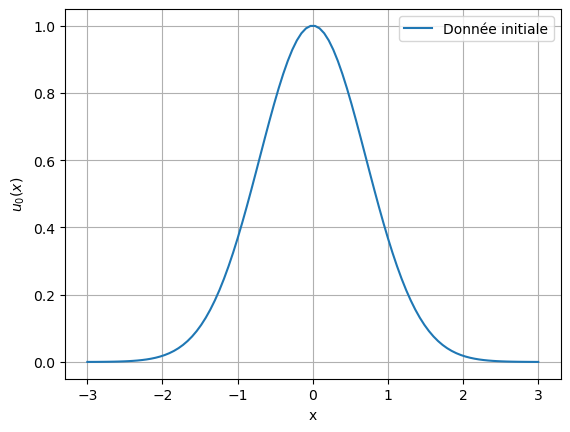

In [4]:
plt.plot(np.linspace(-3, 3, 100), u_init(np.linspace(-3, 3, 100)), label="Donnée initiale")
plt.xlabel('x')
plt.ylabel('$u_0(x)$')
plt.legend()
plt.grid()
plt.show()

Je construis ma solution de référence

/usr/local/anaconda3/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:214: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  warn('spsolve requires A be CSC or CSR matrix format',


Pour dt = 0.000600, nbres iter = 834


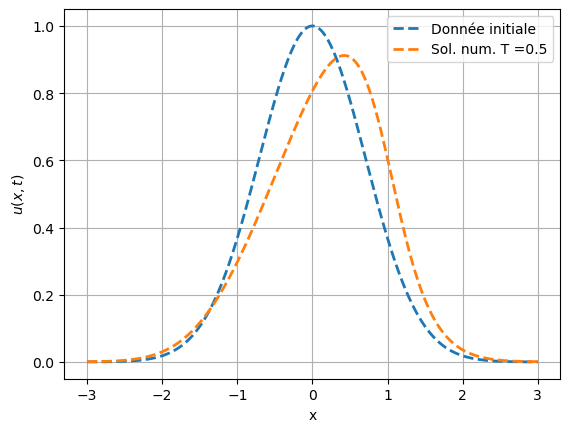

In [5]:
T = 0.5
nu = 0.1
N = 10000
x = np.linspace(-3, 3, N+1)
dx = x[1]-x[0]

dt = dx

t=0
k=0
u = u_init(x)
while t< T:
    umax = max(np.max(np.abs(u)), 1e-10)
    if dt > dx/umax:
        CFL = umax*(dt/dx)
        print("CFL non respectée, CFL = ", CFL)

    #Étape 1: Advection
    u_star = upwind(u, dx, dt)

    #Étape 2: Diffusion (eq de la chaleur)
    u = impicit_diffusion(u_star, dx, dt, nu)

    t+=dt
    k+=1
print(f"Pour dt = {dt:.6f}, nbres iter = {k}")


plt.plot(x, u_init(x), '--',linewidth=2, label="Donnée initiale")
plt.plot(x, u, '--',linewidth=2, label=f"Sol. num. T ={T}")
plt.xlabel('x')
plt.ylabel('$u(x, t)$')
plt.legend()
plt.grid()
plt.show()

### Lie Splitting ###

Pour N = 160, nbres iter = 1000
Pour N = 320, nbres iter = 1000
Pour N = 640, nbres iter = 1000
Pour N = 1280, nbres iter = 1000
Pour N = 160, nbres iter = 2001
Pour N = 320, nbres iter = 2001
Pour N = 640, nbres iter = 2001
Pour N = 1280, nbres iter = 2001
Pour N = 160, nbres iter = 4001
Pour N = 320, nbres iter = 4001
Pour N = 640, nbres iter = 4001
Pour N = 1280, nbres iter = 4001
Pour N = 160, nbres iter = 8000
Pour N = 320, nbres iter = 8000
Pour N = 640, nbres iter = 8000
Pour N = 1280, nbres iter = 8000
Ordre en espace pour dt = 0.0005 vaut : 1.0392190732115287
Ordre en espace pour dt = 0.00025 vaut : 1.019616208583902
Ordre en espace pour dt = 0.000125 vaut : 1.019616208583902
Ordre en espace pour dt = 6.25e-05 vaut : 1.0042382872862563
Ordre en temps pour N = 160 vaut : 1.0392190732115134
Ordre en temps pour N = 320 vaut : 1.0196162085838871
Ordre en temps pour N = 640 vaut : 1.0196162085838871
Ordre en temps pour N = 1280 vaut : 1.0042382872862414


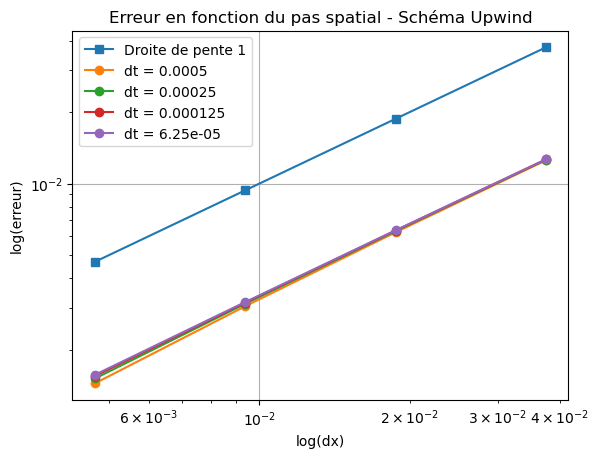

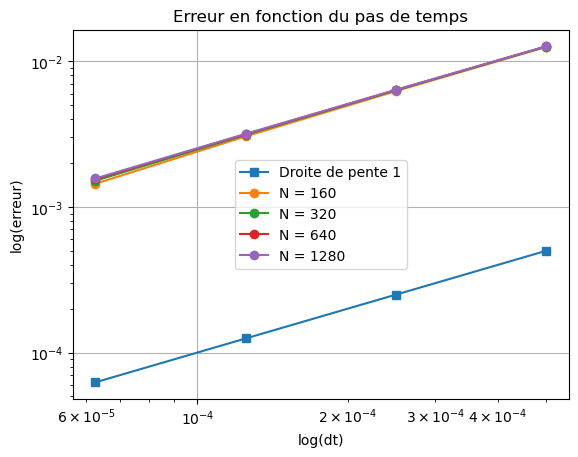

In [6]:
####################################### Pour dt fixe
N1, N2, N3, N4 = 160, 320, 640, 1280
N_vals = [N1, N2, N3, N4]
dx_vals1 = []
dtt1, dtt2, dtt3, dtt4 = 0.5*1e-3, 0.25*1e-3, 0.125*1e-3, 0.0625*1e-3
erreurs1 = []
erreurs2 = []
erreurs3 = []
erreurs4 = []

for N in N_vals:
    xN = np.linspace(-3, 3, N+1)
    dxN = xN[1] - xN[0]
    dx_vals1.append(dxN)
    t=0
    k=0
    uN = u_init(xN)
    while t< T:
        umaxN = max(np.max(np.abs(uN)), 1e-10)
        dt = dtt1
        if dt > dxN/umaxN:
            #CFL = umaxN*(dtt1/dxN)
            #print("CFL non respectée, CFL = ", CFL)
            dt = min(dt, 0.5*dxN/umaxN)

        #Étape 1: Advection
        u_starN = upwind(uN, dxN, dt)

        #Étape 2: Diffusion (eq de la chaleur)
        uN = impicit_diffusion(u_starN, dxN, dt, nu)


        t+=dt
        k+=1
    print(f"Pour N = {N}, nbres iter = {k}")
    f= interp1d(xN, uN, kind='linear', bounds_error=False, fill_value=(uN[0], uN[-1])) #interpolation linéaire de la solution num
    uN_interp = f(x)
    err1 = np.max(np.abs(u - uN_interp))
    erreurs1.append(err1)



####################################### Pour un dt fixe

for N in N_vals:
    xN = np.linspace(-3, 3, N+1)
    dxN = xN[1] - xN[0]
    t=0
    k=0
    uN = u_init(xN)
    while t< T:
        umaxN = max(np.max(np.abs(uN)), 1e-10)
        dt = dtt2
        if dt > dxN/umaxN:
            #CFL = umaxN*(dtt2/dxN)
            #print("CFL non respectée, CFL = ", CFL)
            dt = min(dt, 0.5*dxN/umaxN)

        #Étape 1: Advection
        u_starN = upwind(uN, dxN, dt)

        #Étape 2: Diffusion (eq de la chaleur)
        uN = impicit_diffusion(u_starN, dxN, dt, nu)

        t+=dt
        k+=1
    print(f"Pour N = {N}, nbres iter = {k}")
    f= interp1d(xN, uN, kind='linear', bounds_error=False, fill_value=(uN[0], uN[-1])) #interpolation linéaire de la solution num
    uN_interp = f(x)
    err2 = np.max(np.abs(u - uN_interp))
    erreurs2.append(err2)



####################################### Pour un dt fixe

for N in N_vals:
    xN = np.linspace(-3, 3, N+1)
    dxN = xN[1] - xN[0]
    t=0
    k=0
    uN = u_init(xN)
    while t< T:
        umaxN = max(np.max(np.abs(uN)), 1e-10)
        dt = dtt3
        if dt > dxN/umaxN:
            #CFL = umaxN*(dtt3/dxN)
            #print("CFL non respectée, CFL = ", CFL)
            dt = min(dt, 0.5*dxN/umaxN)

        #Étape 1: Advection
        u_starN = upwind(uN, dxN, dt)

        #Étape 2: Diffusion (eq de la chaleur)
        uN = impicit_diffusion(u_starN, dxN, dt, nu)

        t+=dt
        k+=1
    print(f"Pour N = {N}, nbres iter = {k}")
    f= interp1d(xN, uN, kind='linear', bounds_error=False, fill_value=(uN[0], uN[-1])) #interpolation linéaire de la solution num
    uN_interp = f(x)
    err3 = np.max(np.abs(u - uN_interp))
    erreurs3.append(err3)


####################################### Pour un dt fixe

for N in N_vals:
    xN = np.linspace(-3, 3, N+1)
    dxN = xN[1] - xN[0]
    t=0
    k=0
    uN = u_init(xN)
    while t< T:
        umaxN = max(np.max(np.abs(uN)), 1e-10)
        dt = dtt4
        if dt > dxN/umaxN:
            # CFL = umaxN*(dtt4/dxN)
            # print("CFL non respectée, CFL = ", CFL)
            dt = min(dt, 0.5*dxN/umaxN)


        #Étape 1: Advection
        u_starN = upwind(uN, dxN, dt)

        #Étape 2: Diffusion (eq de la chaleur)
        uN = impicit_diffusion(u_starN, dxN, dt, nu)


        t+=dt
        k+=1
    print(f"Pour N = {N}, nbres iter = {k}")
    f= interp1d(xN, uN, kind='linear', bounds_error=False, fill_value=(uN[0], uN[-1])) #interpolation linéaire de la solution num
    uN_interp = f(x)
    err4 = np.max(np.abs(u - uN_interp))
    erreurs4.append(err4)


dt_vals = np.array([dtt1, dtt2, dtt3, dtt4])
log_dt = np.log(dt_vals)
log_dx1 = np.log(dx_vals1)
log_Erreur1 = np.log(erreurs1)
log_Erreur2 = np.log(erreurs2)
log_Erreur3 = np.log(erreurs3)
log_Erreur4 = np.log(erreurs4)


pente_x1, _ = np.polyfit(log_dx1, log_Erreur1, 1)
pente_x2, _ = np.polyfit(log_dx1, log_Erreur2, 1)
pente_x3, _ = np.polyfit(log_dx1, log_Erreur2, 1)
pente_x4, _ = np.polyfit(log_dx1, log_Erreur4, 1)


pente_t1, _ = np.polyfit(log_dt, log_Erreur1, 1)
pente_t2, _ = np.polyfit(log_dt, log_Erreur2, 1)
pente_t3, _ = np.polyfit(log_dt, log_Erreur2, 1)
pente_t4, _ = np.polyfit(log_dt, log_Erreur4, 1)

print(f"Ordre en espace pour dt = {dtt1} vaut : {pente_x1}")
print(f"Ordre en espace pour dt = {dtt2} vaut : {pente_x2}")
print(f"Ordre en espace pour dt = {dtt3} vaut : {pente_x3}")
print(f"Ordre en espace pour dt = {dtt4} vaut : {pente_x4}")


print(f"Ordre en temps pour N = {N1} vaut : {pente_t1}")
print(f"Ordre en temps pour N = {N2} vaut : {pente_t2}")
print(f"Ordre en temps pour N = {N3} vaut : {pente_t3}")
print(f"Ordre en temps pour N = {N4} vaut : {pente_t4}")

plt.loglog(dx_vals1, dx_vals1, 's-',label="Droite de pente 1")
plt.loglog(dx_vals1, erreurs1, 'o-',label=f"dt = {dtt1}")
plt.loglog(dx_vals1, erreurs2, 'o-', label=f"dt = {dtt2}")
plt.loglog(dx_vals1, erreurs3, 'o-',label=f"dt = {dtt3}")
plt.loglog(dx_vals1, erreurs4, 'o-', label=f"dt = {dtt4}")
plt.xlabel("log(dx)")
plt.ylabel("log(erreur)")
plt.title('Erreur en fonction du pas spatial - Schéma Upwind')
plt.grid()
plt.legend()
plt.show()


plt.loglog(dt_vals, dt_vals, 's-',label="Droite de pente 1")
plt.loglog(dt_vals, erreurs1, 'o-',label=f"N = {N1}")
plt.loglog(dt_vals, erreurs2, 'o-', label=f"N = {N2}")
plt.loglog(dt_vals, erreurs3, 'o-',label=f"N = {N3}")
plt.loglog(dt_vals, erreurs4, 'o-', label=f"N = {N4}")
plt.xlabel("log(dt)")
plt.ylabel("log(erreur)")
plt.title('Erreur en fonction du pas de temps')
plt.grid()
plt.legend()
plt.show()


In [7]:
print("erreurs1: ", erreurs1)
print("erreurs2: ", erreurs2)
print("erreurs3: ", erreurs3)
print("erreurs4: ", erreurs4)

erreurs1:  [0.012534995925713388, 0.006237314269482819, 0.0030474076865194544, 0.0014422022744723373]
erreurs2:  [0.012606861210432752, 0.0063129858458834676, 0.0031205249372965316, 0.0015117935271621308]
erreurs3:  [0.012638261170544673, 0.006345533943048376, 0.003155062809394815, 0.0015480707488655376]
erreurs4:  [0.012652831610610815, 0.0063604025438906975, 0.0031728642319641676, 0.0015673979532440097]


### Strang Splitting ###

Pour dt = 0.000600, nbres iter = 834


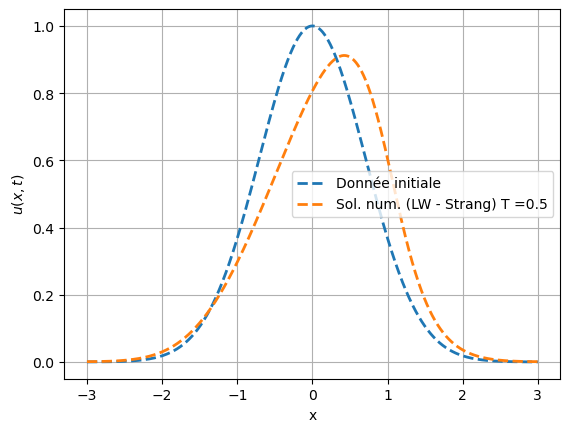

In [8]:
T = 0.5
nu = 0.1
N = 10000
x = np.linspace(-3, 3, N+1)
dx = x[1]-x[0]

dt = dx

t=0
k=0
u = u_init(x)
while t< T:
    umax = max(np.max(np.abs(u)), 1e-10)
    if dt > dx/umax:
        CFL = umax*(dt/dx)
        print("CFL non respectée, CFL = ", CFL)

    #Étape 1: Advection
    u_star = lax_wendroff(u, dx, dt/2)

    #Étape 2: Diffusion (eq de la chaleur)
    uStar = crank_nicolson_diffusion(u_star, dx, dt, nu)

    #Étape 3: Advection
    u = lax_wendroff(uStar, dx, dt/2)

    t+=dt
    k+=1
print(f"Pour dt = {dt:.6f}, nbres iter = {k}")


plt.plot(x, u_init(x), '--',linewidth=2, label="Donnée initiale")
plt.plot(x, u, '--',linewidth=2, label=f"Sol. num. (LW - Strang) T ={T}")
plt.xlabel('x')
plt.ylabel('$u(x, t)$')
plt.legend()
plt.grid()
plt.show()

Pour N = 20, nbres iter = 1000
Pour N = 40, nbres iter = 1000
Pour N = 80, nbres iter = 1000
Pour N = 160, nbres iter = 1000
Pour N = 20, nbres iter = 2001
Pour N = 40, nbres iter = 2001
Pour N = 80, nbres iter = 2001
Pour N = 160, nbres iter = 2001
Pour N = 20, nbres iter = 4001
Pour N = 40, nbres iter = 4001
Pour N = 80, nbres iter = 4001
Pour N = 160, nbres iter = 4001
Pour N = 20, nbres iter = 8000
Pour N = 40, nbres iter = 8000
Pour N = 80, nbres iter = 8000
Pour N = 160, nbres iter = 8000
Ordre en espace pour dt = 0.0005 vaut : 1.7928325208827978
Ordre en espace pour dt = 0.00025 vaut : 1.879393102232956
Ordre en espace pour dt = 0.000125 vaut : 1.879393102232956
Ordre en espace pour dt = 6.25e-05 vaut : 1.792810599208917
Ordre en temps pour N = 20 vaut : 1.7928325208827944
Ordre en temps pour N = 40 vaut : 1.8793931022329506
Ordre en temps pour N = 80 vaut : 1.8793931022329506
Ordre en temps pour N = 160 vaut : 1.792810599208913


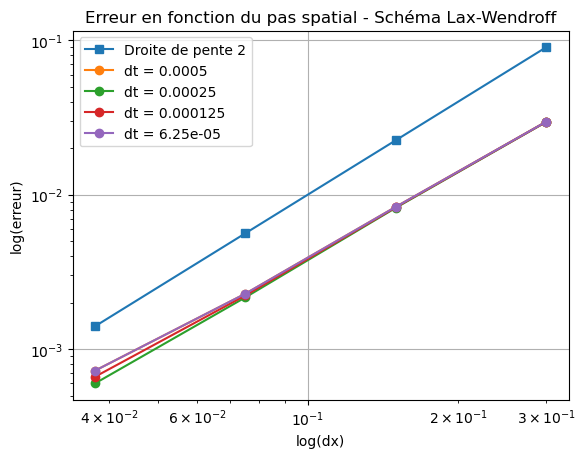

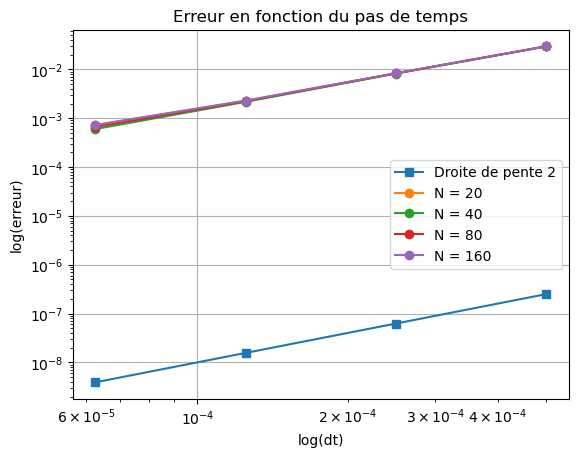

In [9]:
####################################### Pour dt fixe
N1, N2, N3, N4 = 20, 40, 80, 160
N_vals = [N1, N2, N3, N4]
dx_vals1 = []
dtt1, dtt2, dtt3, dtt4 = 0.5*1e-3, 0.25*1e-3, 0.125*1e-3, 0.0625*1e-3
erreurs1 = []
erreurs2 = []
erreurs3 = []
erreurs4 = []

for N in N_vals:
    xN = np.linspace(-3, 3, N+1)
    dxN = xN[1] - xN[0]
    dx_vals1.append(dxN)
    t=0
    k=0
    uN = u_init(xN)
    while t< T:
        umaxN = max(np.max(np.abs(uN)), 1e-10)
        dt = dtt1
        if dt > dxN/umaxN:
            CFL = umaxN*(dtt1/dxN)
            print("CFL non respectée, CFL = ", CFL)
            #dt = min(dt, 0.5*dxN/umaxN)

        #Étape 1: Advection
        u_starN = lax_wendroff(uN, dxN, dt/2)

        #Étape 2: Diffusion (eq de la chaleur)
        uStarN = crank_nicolson_diffusion(u_starN, dxN, dt, nu)

        #etape 3: Advection
        uN = lax_wendroff(uStarN, dxN, dt/2)


        t+=dt
        k+=1
    print(f"Pour N = {N}, nbres iter = {k}")
    f= interp1d(xN, uN, kind='cubic', bounds_error=False, fill_value=0) #interpolation linéaire de la solution num
    uN_interp = f(x)
    err1 = np.max(np.abs(u - uN_interp))
    erreurs1.append(err1)



####################################### Pour un dt fixe

for N in N_vals:
    xN = np.linspace(-3, 3, N+1)
    dxN = xN[1] - xN[0]
    t=0
    k=0
    uN = u_init(xN)
    while t< T:
        umaxN = max(np.max(np.abs(uN)), 1e-10)
        dt = dtt2
        if dt > dxN/umaxN:
            CFL = umaxN*(dtt2/dxN)
            print("CFL non respectée, CFL = ", CFL)
            #dt = min(dt, 0.5*dxN/umaxN)

        #Étape 1: Advection
        u_starN = lax_wendroff(uN, dxN, dt/2)

        #Étape 2: Diffusion (eq de la chaleur)
        uStarN = crank_nicolson_diffusion(u_starN, dxN, dt, nu)

        #Étape 1: Advection
        uN = lax_wendroff(uStarN, dxN, dt/2)

        t+=dt
        k+=1
    print(f"Pour N = {N}, nbres iter = {k}")
    f= interp1d(xN, uN, kind='cubic', bounds_error=False, fill_value=0) #interpolation linéaire de la solution num
    uN_interp = f(x)
    err2 = np.max(np.abs(u - uN_interp))
    erreurs2.append(err2)



####################################### Pour un dt fixe

for N in N_vals:
    xN = np.linspace(-3, 3, N+1)
    dxN = xN[1] - xN[0]
    t=0
    k=0
    uN = u_init(xN)
    while t< T:
        umaxN = max(np.max(np.abs(uN)), 1e-10)
        dt = dtt3
        if dt > dxN/umaxN:
            CFL = umaxN*(dtt3/dxN)
            print("CFL non respectée, CFL = ", CFL)
            #dt = min(dt, 0.5*dxN/umaxN)


        #Étape 1: Advection
        u_starN = lax_wendroff(uN, dxN, dt/2)

        #Étape 2: Diffusion (eq de la chaleur)
        uStarN = crank_nicolson_diffusion(u_starN, dxN, dt, nu)

        #Étape 1: Advection
        uN = lax_wendroff(uStarN, dxN, dt/2)

        t+=dt
        k+=1
    print(f"Pour N = {N}, nbres iter = {k}")
    f= interp1d(xN, uN, kind='cubic', bounds_error=False, fill_value=0) #interpolation linéaire de la solution num
    uN_interp = f(x)
    err3 = np.max(np.abs(u - uN_interp))
    erreurs3.append(err3)


####################################### Pour un dt fixe

for N in N_vals:
    xN = np.linspace(-3, 3, N+1)
    dxN = xN[1] - xN[0]
    t=0
    k=0
    uN = u_init(xN)
    while t< T:
        umaxN = max(np.max(np.abs(uN)), 1e-10)
        dt = dtt4
        if dt > dxN/umaxN:
            CFL = umaxN*(dtt4/dxN)
            print("CFL non respectée, CFL = ", CFL)
            #dt = min(dt, 0.5*dxN/umaxN)

        #Étape 1: Advection
        u_starN = lax_wendroff(uN, dxN, dt/2)

        #Étape 2: Diffusion (eq de la chaleur)
        uStarN = crank_nicolson_diffusion(u_starN, dxN, dt, nu)

        #Étape 1: Advection
        uN = lax_wendroff(uStarN, dxN, dt/2)

        t+=dt
        k+=1
    print(f"Pour N = {N}, nbres iter = {k}")
    f= interp1d(xN, uN, kind='cubic', bounds_error=False, fill_value=0) #interpolation linéaire de la solution num
    uN_interp = f(x)
    err4 = np.max(np.abs(u - uN_interp))
    erreurs4.append(err4)


dt_vals = np.array([dtt1, dtt2, dtt3, dtt4])
logdt = np.log(dt_vals)
logdx1 = np.log(dx_vals1)
logErreur1 = np.log(erreurs1)
logErreur2 = np.log(erreurs2)
logErreur3 = np.log(erreurs3)
logErreur4 = np.log(erreurs4)


pente_x1, _ = np.polyfit(logdx1, logErreur1, 1)
pente_x2, _ = np.polyfit(logdx1, logErreur2, 1)
pente_x3, _ = np.polyfit(logdx1, logErreur2, 1)
pente_x4, _ = np.polyfit(logdx1, logErreur4, 1)


pente_t1, _ = np.polyfit(logdt, logErreur1, 1)
pente_t2, _ = np.polyfit(logdt, logErreur2, 1)
pente_t3, _ = np.polyfit(logdt, logErreur2, 1)
pente_t4, _ = np.polyfit(logdt, logErreur4, 1)

print(f"Ordre en espace pour dt = {dtt1} vaut : {pente_x1}")
print(f"Ordre en espace pour dt = {dtt2} vaut : {pente_x2}")
print(f"Ordre en espace pour dt = {dtt3} vaut : {pente_x3}")
print(f"Ordre en espace pour dt = {dtt4} vaut : {pente_x4}")


print(f"Ordre en temps pour N = {N1} vaut : {pente_t1}")
print(f"Ordre en temps pour N = {N2} vaut : {pente_t2}")
print(f"Ordre en temps pour N = {N3} vaut : {pente_t3}")
print(f"Ordre en temps pour N = {N4} vaut : {pente_t4}")

plt.loglog(dx_vals1, np.array(dx_vals1)**2, 's-',label="Droite de pente 2")
plt.loglog(dx_vals1, erreurs1, 'o-',label=f"dt = {dtt1}")
plt.loglog(dx_vals1, erreurs2, 'o-', label=f"dt = {dtt2}")
plt.loglog(dx_vals1, erreurs3, 'o-',label=f"dt = {dtt3}")
plt.loglog(dx_vals1, erreurs4, 'o-', label=f"dt = {dtt4}")
plt.xlabel("log(dx)")
plt.ylabel("log(erreur)")
plt.title('Erreur en fonction du pas spatial - Schéma Lax-Wendroff')
plt.grid()
plt.legend()
plt.show()


plt.loglog(dt_vals,dt_vals**2, 's-',label="Droite de pente 2")
plt.loglog(dt_vals, erreurs1, 'o-',label=f"N = {N1}")
plt.loglog(dt_vals, erreurs2, 'o-', label=f"N = {N2}")
plt.loglog(dt_vals, erreurs3, 'o-',label=f"N = {N3}")
plt.loglog(dt_vals, erreurs4, 'o-', label=f"N = {N4}")
plt.xlabel("log(dt)")
plt.ylabel("log(erreur)")
plt.title('Erreur en fonction du pas de temps')
plt.grid()
plt.legend()
plt.show()


### On utilise maintenant le schéma MUSCL pour monter d'ordre en espace ###

### test......... (rien à voir avec les précédents codes) ###

/usr/local/anaconda3/lib/python3.11/site-packages/scipy/sparse/linalg/_dsolve/linsolve.py:214: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  warn('spsolve requires A be CSC or CSR matrix format',


Pour N =50, nbres iter = 5001
Pour N =200, nbres iter = 5001
Pour N =800, nbres iter = 5001
Pour N =3200, nbres iter = 5001


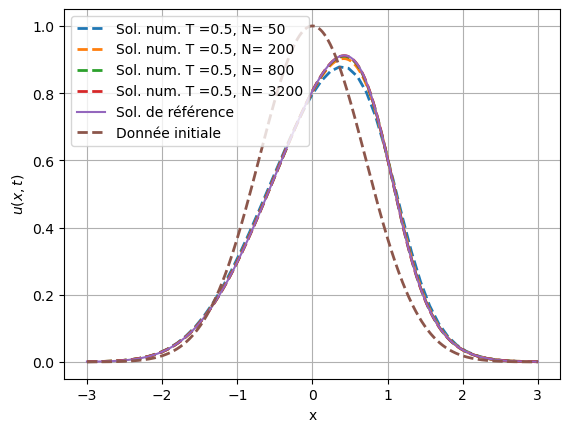

Ordre en espace: 1.0073322904642923
[0.03904576374198121, 0.010133779533510467, 0.0025203742142797525, 0.00059078278245428]


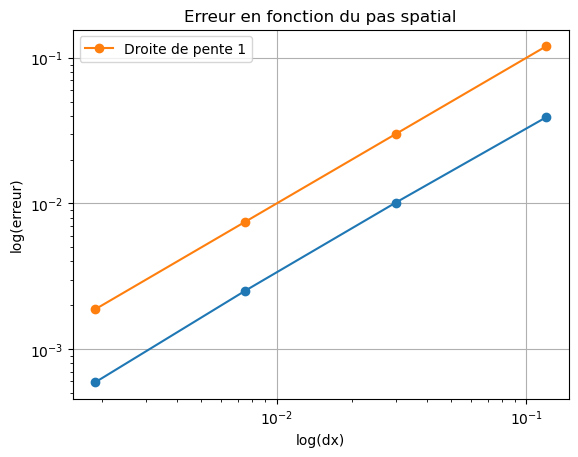

In [14]:
N_vals = [50, 200, 800, 3200]
dt = 1e-4
dx_vals = []
erreurs = []
for N in N_vals:
    xN = np.linspace(-3, 3, N+1)
    dxN = xN[1] - xN[0]
    dx_vals.append(dxN)

    t=0
    k=0
    uN = u_init(xN)
    while t< T:
        umaxN = max(np.max(np.abs(uN)), 1e-10)
        if dt > dxN/umaxN:
            CFL = umaxN*(dtN/dxN)
            print("CFL non respectée, CFL = ", CFL)

        #Étape 1: Advection
        u_starN = upwind(uN, dxN, dt)

        #Étape 2: Diffusion (eq de la chaleur)
        uN = impicit_diffusion(u_starN, dxN, dt, nu)

        t+=dt
        k+=1

    f = interp1d(xN, uN, kind = 'linear', bounds_error=0, fill_value=0)
    uN_interp = f(x)
    erreur = np.max(np.abs(u - uN_interp))
    erreurs.append(erreur)
    print(f"Pour N ={N}, nbres iter = {k}")
    
    plt.plot(xN, uN, '--',linewidth=2, label=f"Sol. num. T ={T}, N= {N}")
plt.plot(x, u, label ="Sol. de référence")
plt.plot(x, u_init(x), '--',linewidth=2, label="Donnée initiale")
plt.xlabel('x')
plt.ylabel('$u(x, t)$')
plt.legend()
plt.grid()
plt.show()

logdx = np.log(dx_vals)
logErreur = np.log(erreurs)
pente_x, _ = np.polyfit(logdx, logErreur, 1)

print(f"Ordre en espace: {pente_x}")

print(erreurs)
plt.loglog(dx_vals, erreurs, 'o-')
plt.loglog(dx_vals, dx_vals, 'o-', label = "Droite de pente 1")
plt.legend()
plt.xlabel("log(dx)")
plt.ylabel("log(erreur)")
plt.title('Erreur en fonction du pas spatial')
plt.grid()
plt.show()


In [33]:
f= interp1d(x, u, kind='linear', bounds_error=False, fill_value=0)
u_interp = f(x1)

error = np.max(np.abs(u1 - u_interp))
print(f"erreur = {error}")

erreur = 0.003792472040924977
